# Experiments with new optimiser
------

## Imports

In [137]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from tqdm import tqdm

## Constants

In [138]:
N = 2 ** 20
N_16 = 2 ** 16
p = 1-e**-2 # our table coverage

## Numerical Optimisation

In [139]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([5 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 2})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Test lower cost bounds with new optimiser

In [140]:
# first do 1.125 1.25 and 1.5 for N = 2^16 like we did for N = 2^20

def test_cost_factors_around_1(N, p, alphas, factors):
    
    # for each factor
    for factor in tqdm(factors, desc="Processing factors"):
        # place to store all the kj's for the factor
        results = []
        
        # for each alpha
        for alpha in tqdm(alphas, desc="Processing alphas"):
            K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
            # plot_kjs_cost(N, K_js, m_0, alpha, factor)
            results.append([K_js, m_0, final_cost, m_values])
            
        # store all kj's for the factor in a .pickle file
        with open(f"N_16/around_1/{factor}P(V)/factor_{factor}_start_5.pickle", "wb") as f:
            pickle.dump(results, f)
        
        # plot all alpha kjs on the same graph
        func.plot_all_alpha(results, N_16, factor)
        

In [141]:
# run all the factors around 1

# factors = [1.5, 1.25, 1.125]
# alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# test_cost_factors_around_1(N_16, p, alphas, factors)

## Compare change in endpoints with different lower bounds

In [142]:
# for lower bounds : 1 , 3, 5
# have two plots : one for change in endpoints and one for change in cost
# one set of graphs for each cost 

def compare_endpoints(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the endpoints for each alpha
        endpoints = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            endpoints.append(res[3][-1])
        
        # plot the endpoints
        ax.plot(endpoints, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Number of endpoints", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in endpoints for different lower bounds for " + factor)
    plt.show()
    

In [143]:
# now similar function to compare change in largest Kj cherry picked from
def compare_kj(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the KJ for each alpha
        kj = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            kj.append(max(res[0]))
        
        # plot the endpoints
        ax.plot(kj, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Largest Kj", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in largest Kj for different lower bounds for " + factor)
    plt.show()

C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_2748\3625074824.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(alphas)


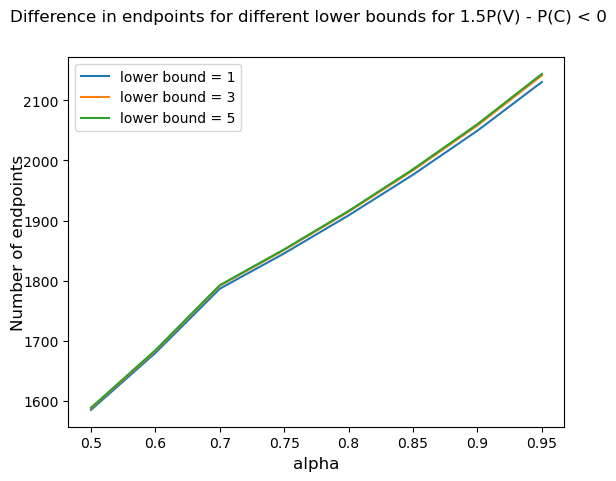

C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_2748\2651133923.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(alphas)


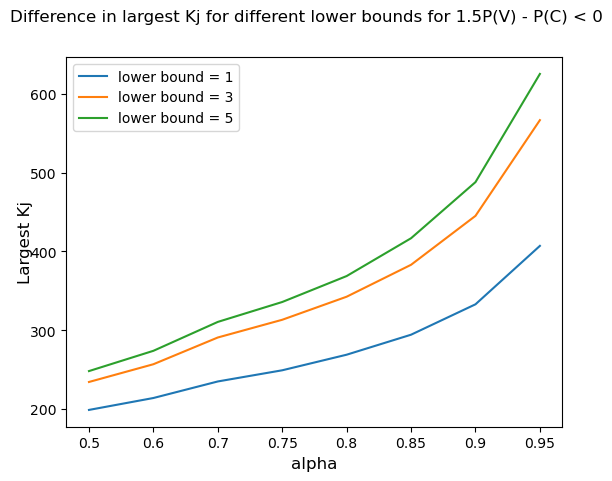

In [144]:
# store bounds 1 3 5
results_list = []

with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_1_new_tol.pickle", "rb") as f:
    results_list.append(pickle.load(f))
    
with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_3.pickle", "rb") as f:
    results_list.append(pickle.load(f))
    
with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_5.pickle", "rb") as f:
    results_list.append(pickle.load(f))
    
bounds = [1, 3, 5]
alphas = [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
factor = "1.5P(V) - P(C) < 0"

compare_endpoints(factor, alphas, bounds, results_list)
compare_kj(factor, alphas, bounds, results_list)


## Test higher costs with new optimiser and bounds

In [145]:
def test_cost_factors(N, p, alpha):
    results = []
    factor = 5
    
    for i in tqdm(range(20), desc="Processing factors"):
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
        results.append([K_js, m_0, final_cost, m_values])
        # increment factor by 5
        factor += 5
        
    return results

In [146]:
def test_all_alpha(N, p):
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    # store results 
    results = []
    
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    
    for alpha in tqdm(alphas, desc="Processing alphas"):
        res = test_cost_factors(N, p, alpha)
        results.append(res)
        
        # now plot them all on the same graph
        # get the title
        func.plot_all_kj(N, res, cost_factors, legend_label, alpha)
        
    return results

In [147]:
def plot_all_results(all_results, N):
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    func.plot_all(N, all_results, cost_factors, legend_label, alphas)

In [148]:
# now run the function
# results = test_all_alpha(N_16, p)
# 
# # store the results in a pickle file
# with open("N_16/higher_costs_new_op_bound_5.pickle", "wb") as f:
#     pickle.dump(results, f)
#     
# # plot on one graph
# plot_all_results(results, N_16) 